In [1]:
from moabb.datasets import *
from moabb.paradigms import P300

dataset = BNCI2014_008()
paradigm = P300(resample=32)
epochs, labels, meta = paradigm.get_data(
    dataset,
    subjects=[1],
    return_epochs=True,
)

Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:392: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


No projector specified for this dataset. Please consider the method self.add_proj.


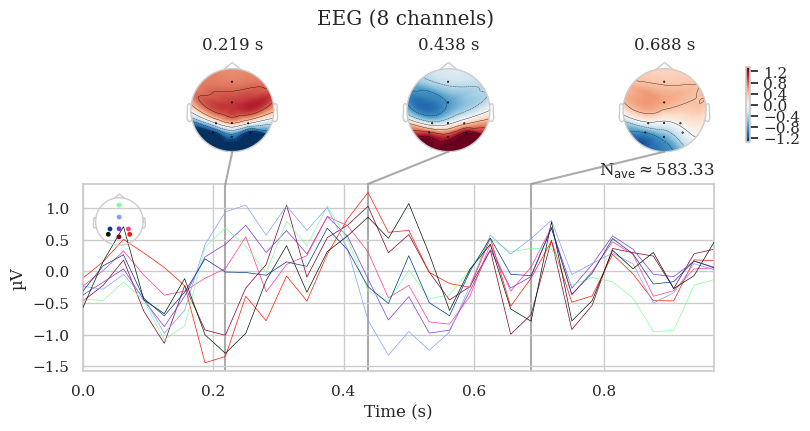

In [2]:
from mne import combine_evoked

target_erp = epochs[labels=='Target'].average()
non_target_erp = epochs[labels=='NonTarget'].average()
contrast = combine_evoked([target_erp, non_target_erp], weights=[1,-1])
contrast.plot_joint();

In [3]:
import tensorly as tl
from bttda.classification import ZScore

X = tl.tensor(epochs.get_data()*1e6)
y = labels
X.shape

(4200, 8, 32)

In [4]:
from bttda.hoda import HODA

hoda = HODA(
        shrinkage='lw',
        obj='tr',
        toeplitz=(1,),
        extra_train_info=True,
        verbose=True,
        theta=0.2,
)


In [5]:
import pandas as pd
from bttda.hoda import solve_gevdh
%pdb on

hoda.fit_backward(X,y)

df = pd.DataFrame(hoda.train_info_['backward'])

Automatic pdb calling has been turned ON


Backward HODA model rank=(1, 4):   9%|▉         | 23/256 [00:00<00:07, 30.41it/s]


In [6]:
df

,iteration,mode,flip,update,shrinkage,objective,F_tr,F_rt
0,1,1,1,7.834146e-01,0.000239,3.861590e+07,0.000864,0.000002
1,1,2,2,1.330743e+00,0.023262,4.049800e+06,0.014067,0.000009
2,2,1,3,7.314529e-01,0.000677,1.540321e+07,0.029341,0.000020
3,2,2,4,3.581121e-01,0.026418,2.761146e+06,0.068784,0.000051
4,3,1,5,4.614300e-01,0.000554,3.891852e+06,0.132885,0.000101
5,3,2,6,1.871530e-01,0.042015,2.541549e+06,0.149889,0.000118
6,4,1,7,3.652182e-01,0.000525,1.667300e+06,0.191500,0.000153
7,4,2,8,1.310665e-01,0.046969,2.584090e+06,0.196567,0.000157
8,5,1,9,1.543321e-01,0.000498,1.103889e+06,0.207447,0.000168
9,5,2,10,1.008731e+00,0.045498,2.752737e+06,0.209784,0.000169


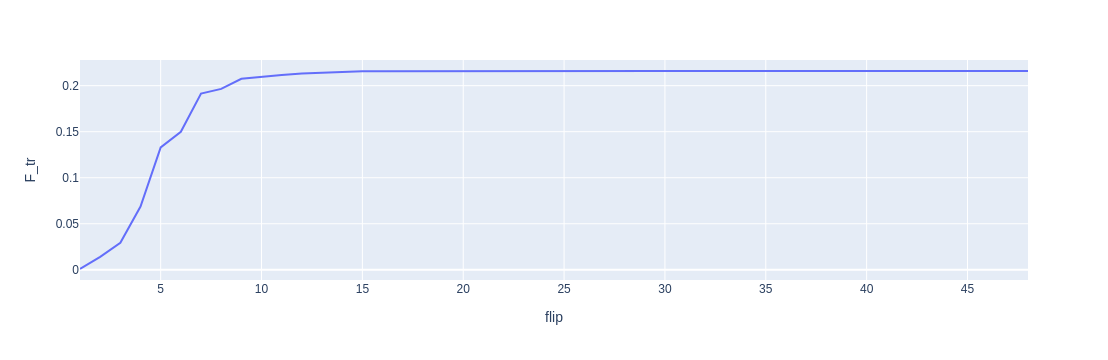

In [7]:
import plotly.express as px

if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_tr')
    fig.show()


In [8]:
if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_rt')
    fig.show()

In [9]:
px.line(df, x='flip', y='update', log_y=True, color='mode')


In [10]:
px.line(df, x='flip', y='shrinkage', log_y=False, color='mode')

In [11]:
px.line(df, x='flip', y='objective', log_y=True, color='mode')

In [12]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

Forward model :  22%|██▏       | 55/255 [00:00<00:02, 76.81it/s]


,iteration,mode,flip,update,lambda_,mse,nmse
0,1,1,1,1.078552e+00,0.0,79.048200,0.998241
1,1,2,2,6.468824e-01,0.0,79.021922,0.997909
2,2,1,3,1.281524e-01,0.0,79.019203,0.997875
3,2,2,4,3.058048e-01,0.0,79.016016,0.997835
4,3,1,5,1.504449e-01,0.0,79.012135,0.997786
...,...,...,...,...,...,...,...
107,54,2,108,9.119046e-09,0.0,78.965012,0.997191
108,55,1,109,1.223135e-08,0.0,78.965012,0.997191
109,55,2,110,6.493677e-09,0.0,78.965012,0.997191
110,56,1,111,8.709950e-09,0.0,78.965012,0.997191


In [13]:
if hoda.extra_train_info:
    px.line(df, x='flip', y='mse', log_y=True)

In [14]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

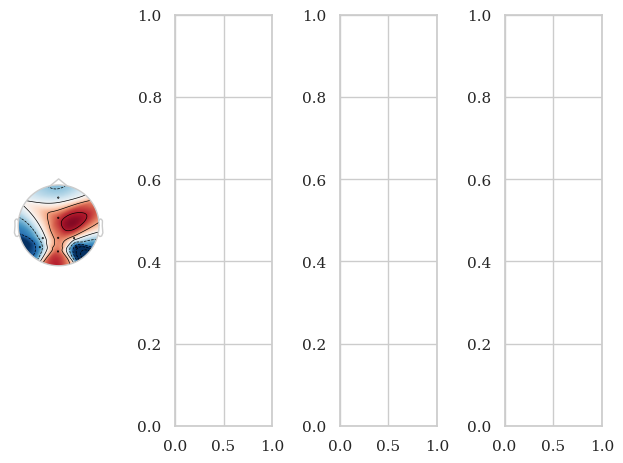

In [15]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

In [16]:
from mne.viz import plot_topomap
from plotly.tools import mpl_to_plotly

# TODO spatial weights
df = pd.DataFrame(tl.to_numpy(hoda.weights_[1]))
df['time'] = epochs.times
df = df.melt(id_vars=['time'], var_name='rank', value_name='weight')
px.line(df, x='time', y='weight', facet_col='rank', facet_col_wrap=4)

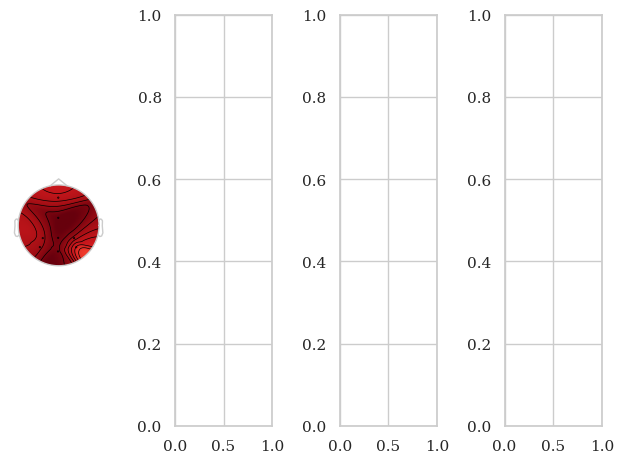

In [17]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])


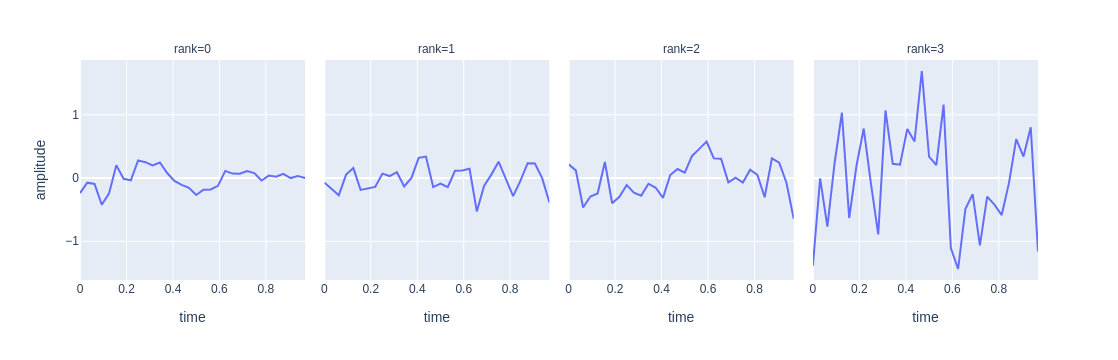

In [18]:
df = pd.DataFrame(tl.to_numpy(hoda.aps_[1]))
df['time'] = epochs.times
df = df.melt(id_vars=['time'], var_name='rank', value_name='amplitude')
px.line(df, x='time', y='amplitude', facet_col='rank', facet_col_wrap=4)

In [19]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from bttda.classification import SelectFCutoff

Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))

select = SelectFCutoff()
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'significant': select.scores_>1,
})
df

,feature,F,significant
0,0,793.280356,True
1,1,0.000002,False
2,2,69.339127,True
3,3,1.157183,True


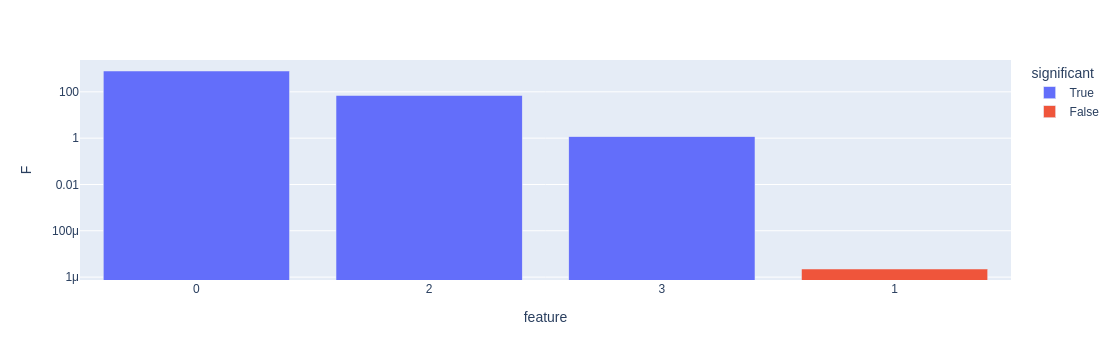

In [20]:
fig = px.bar(df, x='feature', y='F', color='significant', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

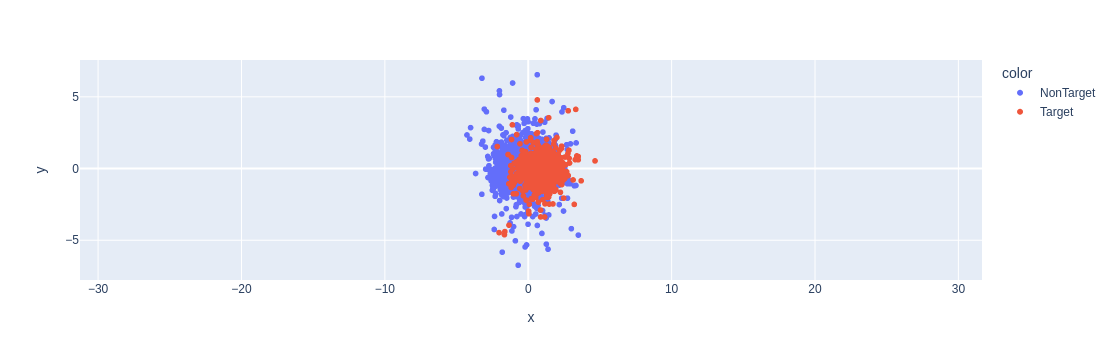

In [21]:
from sklearn.decomposition import PCA

x_viz = PCA(n_components=2, whiten=True).fit_transform(xts)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)
fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
  )

In [22]:
from bttda.hoda import f_multiway

print(f"trace-ratio: {f_multiway(xts,y, method='tr')}")
print(f"ratio-trace: {f_multiway(xts,y, method='rt')}")

trace-ratio: 0.2739448847571122
ratio-trace: 0.0001708103666029443
